# Hiroshima: 대중교통 취약지역과 신규 정류장 우선순위

## 발표용 분석 노트북

이 노트북은 발표에 필요한 내용만 남긴 축약본입니다.

**핵심 질문:** 버스·철도 접근성이 낮고 인구 수요가 큰 지역은 어디이며, 신규 정류장을 어디에 우선 배치할 것인가?

**분석 흐름:** 데이터 결합 → 소지역별 정류장 집계 → 직선거리 기반 비커버 면적 계산 → 인구·수요를 반영한 우선순위 도출

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

warnings.filterwarnings('default')
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data'
OUT_DIR = BASE_DIR / 'outputs'
OUT_DIR.mkdir(exist_ok=True)

ADMIN = DATA_DIR / 'hiroshima_city_admin.gpkg'
BUS = DATA_DIR / 'hiroshima_gtfs_stops_all.gpkg'
STATIONS = DATA_DIR / 'hiroshima_alternative_stations.gpkg'

print('presentation pack:', BASE_DIR)

presentation pack: C:\github\gis_session\hiroshima_presentation


## 1. 데이터와 기준

- 행정구역·기초 인구: 저장소에 포함된 히로시마시 소지역 경계·인구 파일
- 버스: 히로시마현 GTFS-JP 6개 사업자 정류장
- 철도·전차: JR·Astram 역 CSV
- 공급량 단위: GTFS의 정류장·역 포인트(동일 정류장의 승강장/사업자 중복 가능)
- 분석 CRS: EPSG:6670 (미터 단위)
- 버스 접근 반경: 300m
- 철도·전차 접근 반경: 500m

인구 자료는 경계 파일에 포함된 기준연도 인구값을 분석에 사용합니다. 별도 CSV는 최신 공식 월말 자료이며, 일부 소지역은 개인정보 보호를 위해 인접 지역과 합산될 수 있어 이번 순위 계산에는 직접 사용하지 않고 기준 확인용으로 포함했습니다.

In [2]:
gdf_admin = gpd.read_file(ADMIN).rename(columns={'KEY_CODE': 'region_id', 'pop': 'population'})
gdf_admin = gdf_admin[['region_id', 'region_nm', 'ward_nm', 'population', 'geometry']].copy()
gdf_admin['population'] = pd.to_numeric(gdf_admin['population'], errors='coerce').fillna(0)
gdf_admin = gdf_admin.dissolve(
    by='region_id',
    aggfunc={'region_nm': 'first', 'ward_nm': 'first', 'population': 'sum'},
).reset_index().to_crs(6670)

gdf_bus = gpd.read_file(BUS).to_crs(6670)
gdf_station = gpd.read_file(STATIONS).to_crs(6670)

print(f'소지역: {len(gdf_admin):,}')
print(f'버스 정류장: {len(gdf_bus):,}')
print(f'철도·전차역: {len(gdf_station):,}')

소지역: 1,121
버스 정류장: 8,144
철도·전차역: 72


## 2. 소지역별 공급량 집계

각 정류장·역을 소지역에 공간조인해 공급량을 계산합니다. 경계선 위 점은 누락되지 않도록 최근접 소지역으로 보완합니다.

In [3]:
def assign_once(points, regions):
    left = points.copy().reset_index(drop=False).rename(columns={'index': '_point_id'})
    right = regions[['region_id', 'geometry']]
    joined = gpd.sjoin(left, right, how='left', predicate='within')
    matched = set(joined.loc[joined.region_id.notna(), '_point_id'])
    missing = left.loc[~left['_point_id'].isin(matched)]
    if not missing.empty:
        nearest = gpd.sjoin_nearest(missing, right, how='left', max_distance=1.0)
        joined = pd.concat([joined[joined.region_id.notna()], nearest], ignore_index=True)
    return joined.sort_values(['_point_id', 'region_id'], na_position='last').drop_duplicates('_point_id')

bus_joined = assign_once(gdf_bus, gdf_admin)
station_joined = assign_once(gdf_station, gdf_admin)
bus_counts = bus_joined.groupby('region_id').size().rename('bus_count')
station_counts = station_joined.groupby('region_id').size().rename('station_count')

gdf = gdf_admin.merge(bus_counts.rename('bus_count'), on='region_id', how='left').merge(
    station_counts.rename('station_count'), on='region_id', how='left'
).fillna({'bus_count': 0, 'station_count': 0})
gdf['area_km2'] = gdf.geometry.area / 1e6
gdf['population_density'] = np.where(gdf.area_km2 > 0, gdf.population / gdf.area_km2, np.nan)
assert gdf['bus_count'].sum() > 0 and gdf['station_count'].sum() > 0
print(gdf[['bus_count', 'station_count']].sum())

bus_count        3763.0
station_count      55.0
dtype: float64


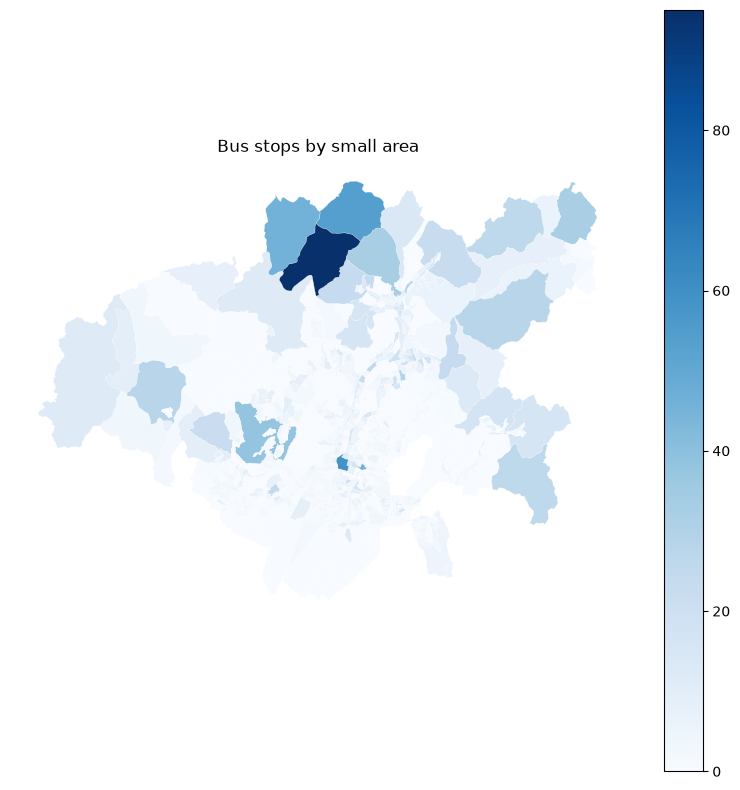

In [4]:
# 공급량 지도
fig, ax = plt.subplots(figsize=(8, 8))
gdf.plot(column='bus_count', cmap='Blues', legend=True, linewidth=0.15, edgecolor='white', ax=ax)
ax.set_title('Bus stops by small area')
ax.set_axis_off()
fig.tight_layout()
fig.savefig(OUT_DIR / '01_bus_supply.png', dpi=180, bbox_inches='tight')
plt.show()

## 3. 비커버 영역 계산

버스 300m, 철도·전차 500m 버퍼의 합집합을 커버리지로 정의합니다. 소지역에서 커버리지를 뺀 면적 비율이 직선거리 기준 비커버율입니다.

In [5]:
bus_coverage = gdf_bus.geometry.buffer(300).union_all()
station_coverage = gdf_station.geometry.buffer(500).union_all()
coverage = bus_coverage.union(station_coverage)

gdf['uncovered_geometry'] = gdf.geometry.difference(coverage)
gdf['uncovered_area_m2'] = gdf.uncovered_geometry.area
gdf['uncovered_ratio'] = (gdf.uncovered_area_m2 / gdf.geometry.area).clip(0, 1)

# 인구가 많고, 비커버율이 높으며, 정류장 공급이 적은 지역을 우선순위로 계산
pop_score = gdf.population_density.rank(pct=True).fillna(0)
unc_score = gdf.uncovered_ratio.rank(pct=True).fillna(0)
supply_score = 1 - (gdf.bus_count + gdf.station_count).rank(pct=True).fillna(0)
gdf['priority_score'] = 0.45 * pop_score + 0.40 * unc_score + 0.15 * supply_score

ranking = gdf.sort_values('priority_score', ascending=False)
top10 = ranking[['region_id', 'region_nm', 'ward_nm', 'population', 'population_density', 'bus_count', 'station_count', 'uncovered_ratio', 'priority_score']].head(10)
top10.to_csv(OUT_DIR / 'top10_priority_areas.csv', index=False, encoding='utf-8-sig')
top10

,region_id,region_nm,ward_nm,population,population_density,bus_count,station_count,uncovered_ratio,priority_score
1031,34108948004,海老園四丁目,広島市佐伯区,1327,15532.971452,0.0,0.0,1.000000,0.932649
1036,34108949005,楽々園五丁目,広島市佐伯区,1945,15574.615986,0.0,0.0,0.973476,0.912756
1037,34108949006,楽々園六丁目,広島市佐伯区,1281,13898.862212,0.0,0.0,1.000000,0.907538
1041,34108951001,美の里一丁目,広島市佐伯区,1673,13214.580883,0.0,0.0,1.000000,0.900312
477,34104416003,井口三丁目,広島市西区,2382,12454.817561,0.0,0.0,1.000000,0.897725
460,34104405001,南観音一丁目,広島市西区,2322,13881.209945,0.0,0.0,0.912408,0.879126
1105,34108989001,海老山南一丁目,広島市佐伯区,1137,11269.889634,0.0,0.0,1.000000,0.869982
480,34104417001,井口鈴が台一丁目,広島市西区,1456,15165.457067,0.0,0.0,0.640968,0.854594
439,34104390001,庚午南一丁目,広島市西区,2640,16791.184967,0.0,0.0,0.542987,0.853434
301,34103216003,皆実町三丁目,広島市南区,1310,18152.301314,0.0,0.0,0.458963,0.852096


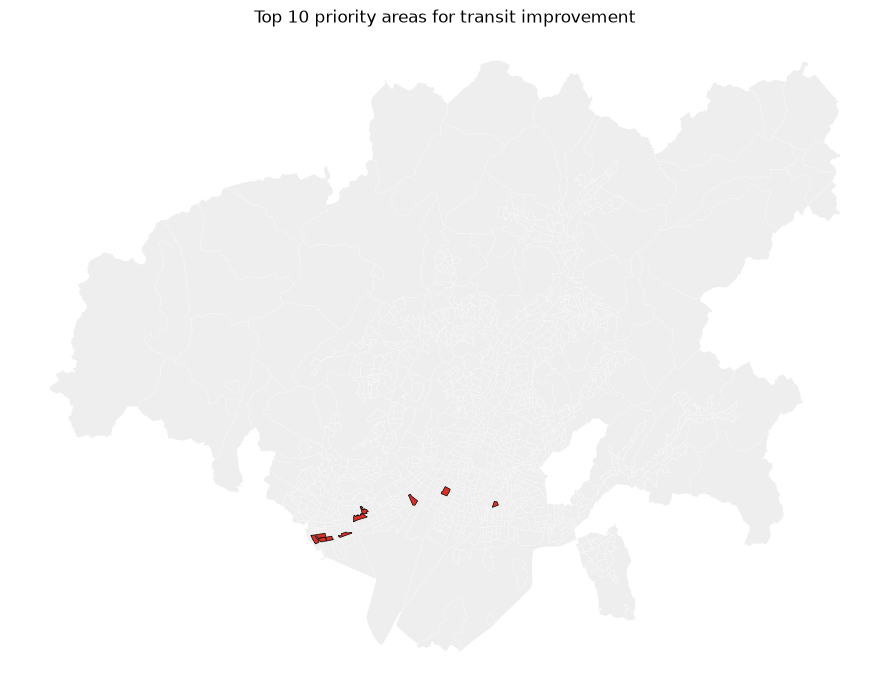

In [6]:
# 우선순위 지도
fig, ax = plt.subplots(figsize=(9, 9))
gdf.plot(ax=ax, facecolor='#eeeeee', edgecolor='white', linewidth=0.15)
ranking.head(10).plot(ax=ax, color='#d73027', edgecolor='black', linewidth=0.5)
ax.set_title('Top 10 priority areas for transit improvement')
ax.set_axis_off()
fig.tight_layout()
fig.savefig(OUT_DIR / '02_priority_areas.png', dpi=180, bbox_inches='tight')
plt.show()

## 4. 발표 핵심 결과

1. 정류장 개수만 보면 외곽·저밀도 지역이 취약지역으로 과대평가될 수 있습니다.
2. 인구밀도와 비커버 면적을 함께 보면, 실제 정책 수요가 큰 주거지역이 우선순위로 이동합니다.
3. 직선거리 버퍼는 1차 선별에는 유용하지만, 도로 단절·육교·하천·실제 보행 우회를 반영하지 못합니다.
4. 따라서 최종 투자 판단 전에는 후보지역에 대해 실제 보행 네트워크와 현장 검토가 필요합니다.

## 5. 한계와 해석상의 주의점

- GTFS는 사업자별 제공 범위가 다르므로 모든 대중교통을 완전히 포함한다고 볼 수 없습니다.
- 인구는 폴리곤 내부에 균등 분포한다고 가정했습니다.
- 300m·500m 버퍼는 직선거리 기준이며 실제 도보거리와 다릅니다.
- 우선순위 점수의 가중치(45/40/15)는 정책적 예시이며, 공식 지표가 아닙니다.
- 결과는 “정류장 설치 위치의 최종 결정”이 아니라 추가 조사가 필요한 후보지 목록입니다.

## 발표 마무리

**결론:** 대중교통 취약지역은 정류장 수가 적은 곳이 아니라, 수요가 큰데 실제 접근 가능한 커버리지가 부족한 곳으로 정의해야 합니다.

**정책 제안:** 상위 후보지역을 대상으로 보행 네트워크 분석, 토지 이용·도로 안전성 검토, 주민 수요조사를 순서대로 진행합니다.